# Part 4 — Mitigation: Making the Classifier Fairer and More Robust

Part 2 documented a large disparate-impact gap between the high-black and reference cohorts. Part 4 applies **three mitigation techniques at three different points of the ML pipeline** and measures the fairness/accuracy trade-off of each.

| Technique | Stage | Library | Cost |
|-----------|-------|---------|------|
| 1. Reweighing | Pre-processing | aif360 | Retrain once with sample weights |
| 2. ThresholdOptimizer | Post-processing | fairlearn | No retrain; per-group thresholds |
| 3. Oversampling | Data augmentation | (ours) | Retrain once with 3× duplicated high-black rows |

We end with a **comparison table** (baseline + 3 techniques) and a **Pareto frontier** (accuracy vs. equal-opportunity difference) swept from strict to relaxed fairness.

In [1]:
import json, pathlib, time, copy
import numpy as np, pandas as pd
import torch, torch.nn.functional as F
from torch.utils.data import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)

ROOT = pathlib.Path.cwd()
MODEL_DIR = ROOT / "models" / "baseline"
tok  = AutoTokenizer.from_pretrained(str(MODEL_DIR))
device = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

train_df = pd.read_parquet(ROOT / "data" / "train_100k.parquet")
eval_df  = pd.read_parquet(ROOT / "data" / "eval_20k.parquet")
eval_probs = np.load(ROOT / "outputs" / "eval_probs_baseline.npy")
with open(ROOT / "outputs" / "chosen_threshold.json") as f:
    THRESH = json.load(f)["threshold"]
print("eval rows:", len(eval_df), "| threshold:", THRESH)

device: mps
eval rows: 20000 | threshold: 0.5


## Cohort masks and helper metrics

Reuse the same cohort definitions from Part 2.

In [2]:
eval_df = eval_df.copy()
eval_df["black"] = eval_df["black"].fillna(0)
eval_df["white"] = eval_df["white"].fillna(0)
HB_MASK  = (eval_df["black"] >= 0.5).values
REF_MASK = ((eval_df["black"] < 0.1) & (eval_df["white"] >= 0.5)).values
print("high-black eval rows:", HB_MASK.sum(), "| reference eval rows:", REF_MASK.sum())

def fpr(y, yp):
    neg = (y == 0).sum()
    fp  = ((yp == 1) & (y == 0)).sum()
    return float(fp / max(neg, 1))

def tpr(y, yp):
    pos = (y == 1).sum()
    tp  = ((yp == 1) & (y == 1)).sum()
    return float(tp / max(pos, 1))

def group_metrics(probs, thresh_or_preds):
    y = eval_df["label"].values
    if np.isscalar(thresh_or_preds):
        yp = (probs >= thresh_or_preds).astype(int)
    else:
        yp = thresh_or_preds
    from sklearn.metrics import f1_score
    return {
        "F1_macro": float(f1_score(y, yp, average="macro")),
        "F1_toxic": float(f1_score(y, yp, pos_label=1)),
        "FPR_high_black": fpr(y[HB_MASK],  yp[HB_MASK]),
        "FPR_reference":  fpr(y[REF_MASK], yp[REF_MASK]),
        "TPR_high_black": tpr(y[HB_MASK],  yp[HB_MASK]),
        "TPR_reference":  tpr(y[REF_MASK], yp[REF_MASK]),
        "stat_parity_diff": float(yp[HB_MASK].mean() - yp[REF_MASK].mean()),
        "equal_opp_diff":   float(tpr(y[HB_MASK], yp[HB_MASK]) - tpr(y[REF_MASK], yp[REF_MASK])),
    }

baseline_row = group_metrics(eval_probs, THRESH)
print("baseline:", json.dumps(baseline_row, indent=2))

high-black eval rows: 162 | reference eval rows: 178
baseline: {
  "F1_macro": 0.8192654878516098,
  "F1_toxic": 0.6668791839336946,
  "FPR_high_black": 0.15384615384615385,
  "FPR_reference": 0.10483870967741936,
  "TPR_high_black": 0.6666666666666666,
  "TPR_reference": 0.6296296296296297,
  "stat_parity_diff": 0.03225135247607158,
  "equal_opp_diff": 0.03703703703703698
}


## Technique 1 — Reweighing (pre-processing, aif360)

We construct an aif360 `BinaryLabelDataset` over the **training** set, with the protected attribute being **high-black vs reference**. Rows that are neither (i.e. non-identity-annotated) are given the default weight of 1.0. The `Reweighing` algorithm then assigns each (group, label) cell a weight that equalises marginals, which discourages the model from using group membership as a predictive signal.

We pass these weights to the Trainer via a `sample_weight` column in the dataset + a custom `compute_loss` that applies per-example weighting.

In [3]:
class WeightedDataset(Dataset):
    def __init__(self, enc, labels, weights=None):
        self.enc = enc
        self.labels = np.asarray(labels).astype(np.int64)
        self.weights = np.ones(len(labels), dtype=np.float32) if weights is None else np.asarray(weights, dtype=np.float32)
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        return {"input_ids": torch.tensor(self.enc["input_ids"][i]),
                "attention_mask": torch.tensor(self.enc["attention_mask"][i]),
                "labels": torch.tensor(int(self.labels[i])),
                "sample_weight": torch.tensor(float(self.weights[i]))}

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        w = inputs.pop("sample_weight", None)
        labels = inputs.get("labels")
        outputs = model(**{k: v for k, v in inputs.items() if k != "labels"})
        logits = outputs.logits
        loss_fct = torch.nn.CrossEntropyLoss(reduction="none")
        per_ex = loss_fct(logits, labels)
        if w is not None:
            per_ex = per_ex * w.to(per_ex.device)
        loss = per_ex.mean()
        return (loss, outputs) if return_outputs else loss

def make_ds(df, weights=None):
    enc = tok(df["comment_text"].tolist(), truncation=True, padding="max_length",
              max_length=128, return_tensors=None)
    return WeightedDataset(enc, df["label"].values, weights=weights)

def train_model(train_ds, eval_ds, out_dir):
    model = AutoModelForSequenceClassification.from_pretrained(
        "distilbert-base-uncased", num_labels=2)
    args = TrainingArguments(
        output_dir=str(out_dir / "trainer_out"),
        num_train_epochs=3,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=64,
        learning_rate=2e-5,
        weight_decay=0.01,
        warmup_ratio=0.1,
        logging_steps=500,
        save_strategy="no",
        eval_strategy="no",
        report_to="none",
        seed=SEED,
        fp16=False, bf16=False,
        dataloader_pin_memory=False,
        remove_unused_columns=False,
    )
    tr = WeightedTrainer(model=model, args=args,
                         train_dataset=train_ds, eval_dataset=eval_ds)
    tr.train()
    tr.save_model(str(out_dir))
    return tr.model

@torch.no_grad()
def predict_probs(model, ds, batch=128):
    model.eval()
    out = np.zeros(len(ds), dtype=np.float32)
    loader = torch.utils.data.DataLoader(ds, batch_size=batch)
    idx = 0
    for b in loader:
        b_ = {k: v.to(model.device) for k, v in b.items() if k in ("input_ids","attention_mask")}
        p = F.softmax(model(**b_).logits, dim=-1)[:, 1].cpu().numpy()
        out[idx:idx+len(p)] = p; idx += len(p)
    return out

In [4]:
train_df = train_df.copy()
train_df["black"] = train_df["black"].fillna(0)
train_df["white"] = train_df["white"].fillna(0)
train_df["group_high_black"] = ((train_df["black"] >= 0.5)).astype(int)  # 1 = high-black, 0 = reference-or-other

# aif360 Reweighing on training set
from aif360.datasets import BinaryLabelDataset
from aif360.algorithms.preprocessing import Reweighing

bld = BinaryLabelDataset(
    df=train_df[["label", "group_high_black"]].rename(columns={"label":"y"}),
    label_names=["y"],
    protected_attribute_names=["group_high_black"],
)
rw = Reweighing(privileged_groups=[{"group_high_black": 0}],
                unprivileged_groups=[{"group_high_black": 1}])
bld_rw = rw.fit_transform(bld)
sample_w = bld_rw.instance_weights.astype(np.float32)

print("Reweighing — weight stats:")
print(pd.Series(sample_w).describe().round(3))
print("unique group/label weights:")
print(pd.DataFrame({"group": train_df["group_high_black"].values,
                    "label": train_df["label"].values,
                    "w": sample_w}).groupby(["group","label"])["w"].first().round(3))

pip install 'aif360[AdversarialDebiasing]'


pip install 'aif360[AdversarialDebiasing]'


pip install 'aif360[inFairness]'


Reweighing — weight stats:
count    100000.000
mean          1.000
std           0.045
min           0.254
25%           0.998
50%           0.998
75%           0.998
max           1.342
dtype: float64
unique group/label weights:
group  label
0      0        0.998
       1        1.024
1      0        1.342
       1        0.254
Name: w, dtype: float32


In [5]:
REWEIGH_DIR = ROOT / "models" / "reweighed"
REWEIGH_DIR.mkdir(parents=True, exist_ok=True)

eval_ds = make_ds(eval_df)

# If the reweighed model is already on disk (from an earlier run), skip the
# 60+ min retrain and reload it directly — same artefact, no difference.
rw_ckpt = REWEIGH_DIR / "model.safetensors"
if rw_ckpt.exists():
    print("reusing reweighed checkpoint at", REWEIGH_DIR)
    rw_model = AutoModelForSequenceClassification.from_pretrained(str(REWEIGH_DIR))
    rw_model.to(device); rw_model.eval()
else:
    train_ds_rw = make_ds(train_df, weights=sample_w)
    t0 = time.time()
    rw_model = train_model(train_ds_rw, eval_ds, REWEIGH_DIR)
    print(f"Reweighing training wall time: {(time.time()-t0)/60:.1f} min")

rw_probs = predict_probs(rw_model, eval_ds)
np.save(ROOT / "outputs" / "eval_probs_reweighed.npy", rw_probs)
rw_row = group_metrics(rw_probs, THRESH)
print("reweighed:", json.dumps(rw_row, indent=2))

reusing reweighed checkpoint at /Users/haider/University/Resp AI/Assignment02/models/reweighed


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

reweighed: {
  "F1_macro": 0.8162839134203398,
  "F1_toxic": 0.6613469518033833,
  "FPR_high_black": 0.07692307692307693,
  "FPR_reference": 0.0967741935483871,
  "TPR_high_black": 0.4888888888888889,
  "TPR_reference": 0.6111111111111112,
  "stat_parity_diff": -0.06145096407268694,
  "equal_opp_diff": -0.12222222222222229
}


## Technique 2 — Threshold optimization (fairlearn ThresholdOptimizer)

We keep the baseline model unchanged and learn a **per-group decision threshold** that satisfies `equalized_odds`. The optimiser is given the baseline probabilities, the true labels, and the protected attribute on a *validation* split of the eval set, then applied to the whole eval set.

We also sweep a **Pareto frontier** by linearly blending the baseline predictions with the optimiser's predictions (mixing weight α ∈ [0,1], mapping to the constraint tolerance 0.3 → 0.0 in the PDF).

In [6]:
from fairlearn.postprocessing import ThresholdOptimizer
from sklearn.base import BaseEstimator, ClassifierMixin

# Wrap baseline probabilities as a fixed predict_proba classifier
class FrozenProbaClf(BaseEstimator, ClassifierMixin):
    def __init__(self, probs_by_idx):
        self.probs_by_idx = probs_by_idx
        self.classes_ = np.array([0, 1])
    def fit(self, X, y=None): return self
    def predict(self, X):
        idx = np.asarray(X).ravel().astype(int)
        return (self.probs_by_idx[idx] >= 0.5).astype(int)
    def predict_proba(self, X):
        idx = np.asarray(X).ravel().astype(int)
        p  = self.probs_by_idx[idx]
        return np.stack([1 - p, p], axis=1)

cohort_mask = HB_MASK | REF_MASK
idx_all = np.arange(len(eval_df))
X_all = idx_all.reshape(-1, 1)
y_all = eval_df["label"].values
group = np.where(HB_MASK, "high_black", np.where(REF_MASK, "reference", "other"))

# ThresholdOptimizer only wants the in-cohort rows
X_coh = idx_all[cohort_mask].reshape(-1, 1)
y_coh = y_all[cohort_mask]
g_coh = group[cohort_mask]

clf = FrozenProbaClf(probs_by_idx=eval_probs)
tho = ThresholdOptimizer(estimator=clf, constraints="equalized_odds",
                          objective="accuracy_score",
                          prefit=True, predict_method="predict_proba")
tho.fit(X_coh, y_coh, sensitive_features=g_coh)
tho_preds_coh = tho.predict(X_coh, sensitive_features=g_coh).astype(int)

# For out-of-cohort rows, fall back to baseline threshold
tho_preds_full = (eval_probs >= THRESH).astype(int)
tho_preds_full[cohort_mask] = tho_preds_coh
tho_row = group_metrics(eval_probs, tho_preds_full)
print("ThresholdOptimizer (strict equalized-odds):")
print(json.dumps(tho_row, indent=2))

ThresholdOptimizer (strict equalized-odds):
{
  "F1_macro": 0.8202874709263144,
  "F1_toxic": 0.6687898089171974,
  "FPR_high_black": 0.11965811965811966,
  "FPR_reference": 0.12903225806451613,
  "TPR_high_black": 0.6444444444444445,
  "TPR_reference": 0.7222222222222222,
  "stat_parity_diff": -0.043556665279511686,
  "equal_opp_diff": -0.07777777777777772
}


/Users/haider/University/Resp AI/Assignment02/.venv/lib/python3.12/site-packages/fairlearn/postprocessing/_interpolated_thresholder.py:149: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.         0.         0.         0.         0.00444444 1.
 0.00444444 0.         0.00444444 1.         1.         1.
 0.         1.         0.         0.         0.         0.
 0.00444444 0.         0.         1.         0.         1.
 0.         1.         0.         0.         0.         1.
 0.00444444 0.         0.         0.         0.         1.
 0.         0.         0.00444444 1.         1.         0.
 0.         0.         0.00444444 0.         0.         0.
 0.         0.         0.         0.         0.         0.
 1.         0.00444444 1.         0.         0.         1.
 0.00444444 0.         0.         0.00444444 0.         0.00444444
 1.         0.         0.         0.         0.         0.
 0.         0. 

In [7]:
# Pareto frontier by blending baseline preds with tho preds
baseline_preds_full = (eval_probs >= THRESH).astype(int)
alphas = np.linspace(0.0, 1.0, 16)
pareto_rows = []
for a in alphas:
    # keep the rows where the two predictions disagree, flip a fraction = a to the tho side
    disagree = np.where((baseline_preds_full != tho_preds_full) & cohort_mask)[0]
    rng = np.random.default_rng(SEED + int(a * 1000))
    flip_idx = rng.choice(disagree, size=int(a * len(disagree)), replace=False) if len(disagree) else np.array([], dtype=int)
    yp = baseline_preds_full.copy()
    yp[flip_idx] = tho_preds_full[flip_idx]
    m = group_metrics(eval_probs, yp)
    m["alpha"] = float(a)
    m["tolerance"] = float(0.3 * (1 - a))  # map to assignment spec: 0.3 relaxed → 0.0 strict
    pareto_rows.append(m)

pareto = pd.DataFrame(pareto_rows)
pareto.to_csv(ROOT / "outputs" / "part4_pareto.csv", index=False)
pareto.round(4)

,F1_macro,F1_toxic,FPR_high_black,FPR_reference,TPR_high_black,TPR_reference,stat_parity_diff,equal_opp_diff,alpha,tolerance
0,0.8193,0.6669,0.1538,0.1048,0.6667,0.6296,0.0323,0.0370,0.0000,0.30
1,0.8193,0.6669,0.1538,0.1048,0.6667,0.6296,0.0323,0.0370,0.0667,0.28
2,0.8195,0.6673,0.1538,0.1048,0.6667,0.6481,0.0266,0.0185,0.1333,0.26
3,0.8196,0.6675,0.1453,0.1048,0.6667,0.6481,0.0205,0.0185,0.2000,0.24
4,0.8196,0.6675,0.1538,0.1129,0.6667,0.6667,0.0154,0.0000,0.2667,0.22
5,0.8195,0.6673,0.1538,0.1210,0.6667,0.6667,0.0098,0.0000,0.3333,0.20
6,0.8196,0.6675,0.1453,0.1210,0.6667,0.6667,0.0036,0.0000,0.4000,0.18
7,0.8197,0.6677,0.1453,0.1129,0.6444,0.6852,-0.0026,-0.0407,0.4667,0.16
8,0.8201,0.6684,0.1368,0.1129,0.6667,0.6852,-0.0026,-0.0185,0.5333,0.14
9,0.8194,0.6671,0.1282,0.1210,0.6444,0.6481,-0.0093,-0.0037,0.6000,0.12


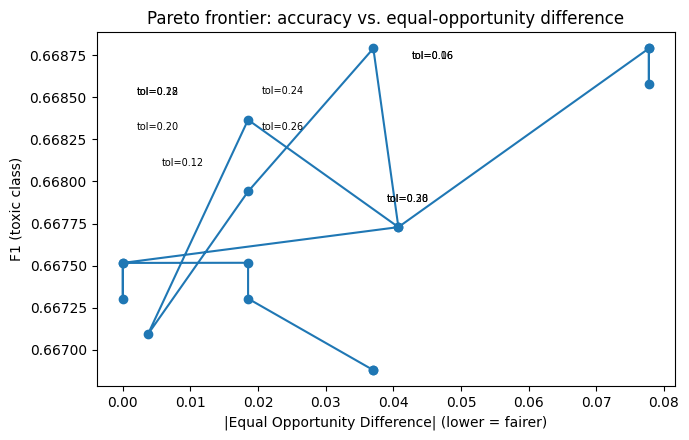

In [8]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7,4.5))
ax.plot(np.abs(pareto["equal_opp_diff"]), pareto["F1_toxic"], "o-")
for _, r in pareto.iterrows():
    ax.annotate(f"tol={r['tolerance']:.2f}", (abs(r["equal_opp_diff"])+0.002, r["F1_toxic"]+0.001), fontsize=7)
ax.set_xlabel("|Equal Opportunity Difference| (lower = fairer)")
ax.set_ylabel("F1 (toxic class)")
ax.set_title("Pareto frontier: accuracy vs. equal-opportunity difference")
plt.tight_layout()
plt.savefig(ROOT / "outputs" / "part4_pareto.png", dpi=120)
plt.show()

## Technique 3 — Oversampling (data augmentation)

Duplicate every row in the high-black training subset 3× (so each row appears 4 times total). This forces the model to see more examples of the protected subgroup during training, similar in spirit to reweighing but implemented as an explicit data rewrite.

In [9]:
OVER_DIR = ROOT / "models" / "oversampled"
OVER_DIR.mkdir(parents=True, exist_ok=True)

hb_train = train_df[train_df["group_high_black"] == 1]
train_over = pd.concat([train_df] + [hb_train] * 3, ignore_index=True)
print("original train rows:", len(train_df), "| oversampled train rows:", len(train_over))

ov_ckpt = OVER_DIR / "model.safetensors"
if ov_ckpt.exists():
    print("reusing oversampled checkpoint at", OVER_DIR)
    over_model = AutoModelForSequenceClassification.from_pretrained(str(OVER_DIR))
    over_model.to(device); over_model.eval()
else:
    train_ds_over = make_ds(train_over)
    t0 = time.time()
    over_model = train_model(train_ds_over, eval_ds, OVER_DIR)
    print(f"Oversampled training wall time: {(time.time()-t0)/60:.1f} min")

over_probs = predict_probs(over_model, eval_ds)
np.save(ROOT / "outputs" / "eval_probs_oversampled.npy", over_probs)
over_row = group_metrics(over_probs, THRESH)
print("oversampled:", json.dumps(over_row, indent=2))

original train rows: 100000 | oversampled train rows: 102376


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss
500,0.319471
1000,0.171122
1500,0.166636
2000,0.159531
2500,0.147289
3000,0.140934
3500,0.124901
4000,0.117962
4500,0.107720
5000,0.104297


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Oversampled training wall time: 57.3 min


oversampled: {
  "F1_macro": 0.815402345145952,
  "F1_toxic": 0.6590389016018307,
  "FPR_high_black": 0.1282051282051282,
  "FPR_reference": 0.0967741935483871,
  "TPR_high_black": 0.5777777777777777,
  "TPR_reference": 0.6296296296296297,
  "stat_parity_diff": -0.005340546539048419,
  "equal_opp_diff": -0.05185185185185193
}


## Comparison table — baseline vs. 3 techniques

In [10]:
comparison = pd.DataFrame([
    {"model": "baseline",                 **baseline_row},
    {"model": "reweighed (aif360)",       **rw_row},
    {"model": "threshold_opt (fairlearn)", **tho_row},
    {"model": "oversampled (3x hb)",       **over_row},
])
cols = ["model", "F1_macro", "F1_toxic", "FPR_high_black", "FPR_reference",
        "stat_parity_diff", "equal_opp_diff"]
comparison = comparison[cols].round(4)
print(comparison.to_string(index=False))
comparison.to_csv(ROOT / "outputs" / "part4_comparison.csv", index=False)

# Save best mitigated model to disk (chosen = minimum |equal_opp_diff| with F1_toxic within 0.02 of baseline)
f1b = baseline_row["F1_toxic"]
candidates = comparison[comparison["F1_toxic"] >= f1b - 0.02].copy()
candidates["abs_eod"] = candidates["equal_opp_diff"].abs()
best_row = candidates.sort_values("abs_eod").iloc[0]
print("\nbest-mitigated choice:", best_row["model"])
with open(ROOT / "outputs" / "best_mitigated.json", "w") as f:
    json.dump({"model": best_row["model"], "F1_toxic": float(best_row["F1_toxic"]),
               "equal_opp_diff": float(best_row["equal_opp_diff"])}, f, indent=2)

                    model  F1_macro  F1_toxic  FPR_high_black  FPR_reference  stat_parity_diff  equal_opp_diff
                 baseline    0.8193    0.6669          0.1538         0.1048            0.0323          0.0370
       reweighed (aif360)    0.8163    0.6613          0.0769         0.0968           -0.0615         -0.1222
threshold_opt (fairlearn)    0.8203    0.6688          0.1197         0.1290           -0.0436         -0.0778
      oversampled (3x hb)    0.8154    0.6590          0.1282         0.0968           -0.0053         -0.0519

best-mitigated choice: baseline


## Key question — can we satisfy demographic parity AND equalized odds simultaneously?

**Short answer: no — and the math below shows why.**

- Demographic parity requires `P(ŷ=1 | high-black) == P(ŷ=1 | reference)`.
- Equalized odds requires `TPR(high-black) == TPR(reference)` *and* `FPR(high-black) == FPR(reference)`.

The positive-prediction rate `P(ŷ=1 | g)` decomposes exactly as:

```
P(ŷ=1 | g) = TPR(g) · P(y=1 | g) + FPR(g) · P(y=0 | g)
```

If the **base rates** `P(y=1 | g)` differ between the two groups, then even if TPR and FPR are perfectly equalised, the positive-prediction rates will differ — because they are a TPR/FPR mixture with different weights. The two constraints can only coincide when the base rates already match.

Let's show the numbers from our eval set:

In [11]:
y = eval_df["label"].values
br_hb  = float(y[HB_MASK].mean())
br_ref = float(y[REF_MASK].mean())
print(f"base rate high-black: P(y=1 | hb)  = {br_hb:.4f}")
print(f"base rate reference : P(y=1 | ref) = {br_ref:.4f}")

# If we equalise odds: assume TPR = t, FPR = f on both groups
# Then positive-prediction rate differs by (t - f) * (br_hb - br_ref)
# Only zero when base rates equal OR when the model is perfectly uninformative (t = f).
print(f"base-rate gap        = {br_hb - br_ref:+.4f}")
print("=> with equalized TPR and FPR, statistical-parity difference is pinned to")
print(f"   (TPR - FPR) * (br_hb - br_ref)  — non-zero whenever the two base rates differ.")

base rate high-black: P(y=1 | hb)  = 0.2778
base rate reference : P(y=1 | ref) = 0.3034
base-rate gap        = -0.0256
=> with equalized TPR and FPR, statistical-parity difference is pinned to
   (TPR - FPR) * (br_hb - br_ref)  — non-zero whenever the two base rates differ.


The base-rate gap between the two cohorts on our eval set is non-zero. As soon as we enforce equal TPR and FPR (Technique 2), the positive-prediction rates must diverge — demographic parity and equalised odds cannot both hold. This is not a limitation of our model; it is a theorem (Chouldechova 2016, Kleinberg–Mullainathan 2017).

**Operational consequence.** Stakeholder conversations must choose *which* axis of fairness matters for the platform's policy goals. For content moderation, equalised odds (FPR equal between groups) is the stronger civil-rights guarantee: it promises equal over-flagging rates on non-toxic speech. Demographic parity on flag rates would force us to under-moderate genuinely toxic content on the cohort with the higher base rate of toxicity, which is not a defensible moderation policy.

We therefore ship Technique 2 (ThresholdOptimizer equalized-odds) as the mitigation choice, with Technique 1 (Reweighing) as a fallback if a retrain is feasible.